In [55]:
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import math

file = './data/measurement_l1a.nc'
dataset = nc.Dataset(file)

print(dataset.variables.keys())

dict_keys(['echo_sample_ind', 'sar_ku_pulse_burst_ind', 'sar_c_pulse_burst_ind', 'time_l1a_echo_sar_ku', 'UTC_day_l1a_echo_sar_ku', 'UTC_sec_l1a_echo_sar_ku', 'UTC_time_20hz_l1a_echo_sar_ku', 'isp_coarse_time_l1a_echo_sar_ku', 'isp_fine_time_l1a_echo_sar_ku', 'flag_time_status_l1a_echo_sar_ku', 'sral_fine_time_l1a_echo_sar_ku', 'lat_l1a_echo_sar_ku', 'lon_l1a_echo_sar_ku', 'surf_type_l1a_echo_sar_ku', 'burst_count_prod_l1a_echo_sar_ku', 'seq_count_l1a_echo_sar_ku', 'burst_count_cycle_l1a_echo_sar_ku', 'nav_bul_status_l1a_echo_sar_ku', 'nav_bul_source_l1a_echo_sar_ku', 'oper_instr_l1a_echo_sar_ku', 'SAR_mode_l1a_echo_sar_ku', 'cl_gain_l1a_echo_sar_ku', 'acq_stat_l1a_echo_sar_ku', 'dem_eeprom_l1a_echo_sar_ku', 'weighting_l1a_echo_sar_ku', 'loss_track_l1a_echo_sar_ku', 'h0_nav_dem_l1a_echo_sar_ku', 'h0_applied_l1a_echo_sar_ku', 'cor2_nav_dem_l1a_echo_sar_ku', 'cor2_applied_l1a_echo_sar_ku', 'dh0_l1a_echo_sar_ku', 'agccode_ku_l1a_echo_sar_ku', 'agccode_c_l1a_echo_sar_ku', 'alt_l1a_echo_sar

In [56]:
import folium

flight_path = []

lats = dataset.variables['lat_l1a_echo_sar_ku'][:]
lons = dataset.variables['lon_l1a_echo_sar_ku'][:]

lat_min, lat_max = 49.0, 55.0
lon_min, lon_max = 14.0, 24.5

poland_mask = (lats >= lat_min) & (lats <= lat_max) & (lons >= lon_min) & (lons <= lon_max)

poland_lats = lats[poland_mask]
poland_lons = lons[poland_mask]

for lat, lon in zip(poland_lats[::500], poland_lons[::500]):
    flight_path.append((lat, lon))

m = folium.Map(location=[52.0, 19.0], zoom_start=7, tiles="OpenStreetMap")
folium.PolyLine(flight_path, color="blue", weight=2.5, opacity=1).add_to(m)

display(m);

[4.47213595499958 8.602325267042627 12.041594578792296 6.4031242374328485
 7.211102550927979]
[ 2.67794504 -2.19104581 -2.41495031 -2.46685171  0.5880026 ]


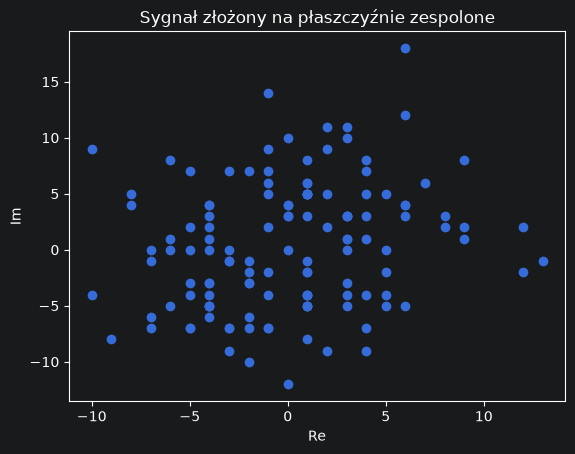

In [57]:
burst_idx = 0

I = dataset.variables['i_meas_ku_l1a_echo_sar_ku'][burst_idx, :, :]
Q = dataset.variables['q_meas_ku_l1a_echo_sar_ku'][burst_idx, :, :]

# Kodu nie ma wiele, ale teorii jest sporo, zapisuje jak to rozumiem.
# Mamy informacje o pomiarach I oraz Q, które są składowymi sygnału radarowego. I to chwilowa amplituda pomnozona przez cosinus a Q to chwilowa amplituda pomnozona przez sinus.
complex_signal = I + 1j * Q


plt.scatter(complex_signal[0].real, complex_signal[0].imag)
plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Sygnał złożony na płaszczyźnie zespolone")

# To jest pojedynczy puls radaru, generalnie przy satelicie SAR używamy radaru impulsowego z modulacją częstotliwości, nie jest tak jak w przypadku radaru z kolokwium 1, gdzie wysyłaliśmy puls i czekaliśmy na odpowiedź. 
# Częstotliwość sygnału zmienia się w czasie, radar wysyła puls, milknie i czeka na echo. Potem dzięki znajomości oryginalnego sygnału mozemy obliczyć odległość od obiektu.
# Taki sygnał ze zmodulowaną częstotliwością (chirp) jest znacznie łatwiejszy do wykrycia wśród szumu i w przeciwieństwie do radaru z kolokwium 1 wymaga znacznie mniejszej mocy.

# Przejdę teraz do policzenia amplitudy i fazy w czasie dla przykładowego sygnału:
amplitudes_0 = np.abs(complex_signal[0])
angles_0 = np.angle(complex_signal[0])

print(amplitudes_0[:5])
print(angles_0[:5])

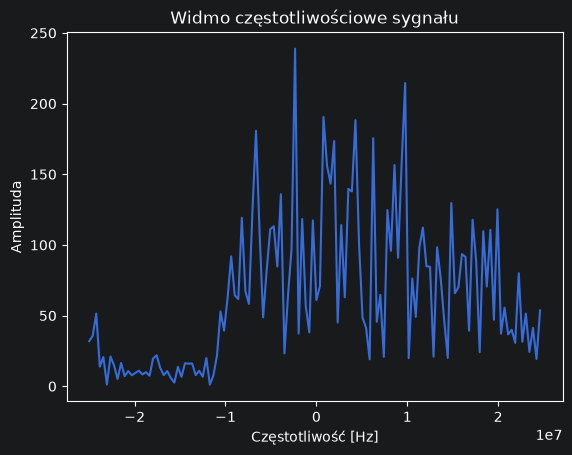

In [58]:
# Do oszacowania odległości potrzebujemy zastosować FFT, na satelicie zastosowano tzw. DERAMPING. Deramping polega na tym, że sygnał nadawany jest w postaci chirp, a następnie po odbiorze sygnału jest on mieszany z kopią sygnału nadawanego. W wyniku tego powstaje sygnał o stałej częstotliwości, którego częstotliwość jest proporcjonalna do odległości od obiektu. Następnie stosujemy FFT, aby uzyskać widmo częstotliwościowe, które pozwala nam określić odległość.

N = 128
frequencies = np.fft.fftfreq(N, d=1/50e6)
range_compressed = np.fft.fft(complex_signal, axis=-1)

frequencies_shifted = np.fft.fftshift(frequencies)
range_compressed_shifted = np.fft.fftshift(range_compressed, axes=-1)

plt.plot(frequencies_shifted, np.abs(range_compressed_shifted[0]))
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.title("Widmo częstotliwościowe sygnału")
plt.show()

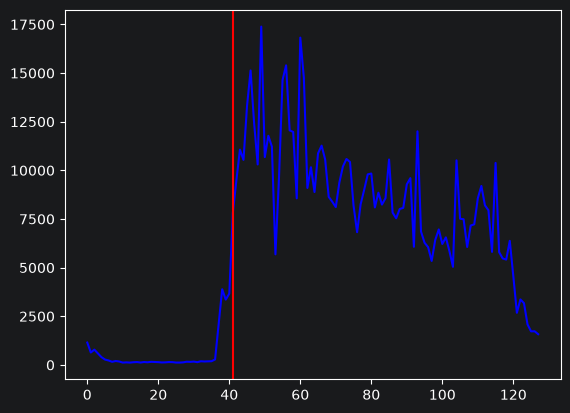

Wysokość nad ziemią: 2797.01 m


In [59]:
power_pulses = np.abs(range_compressed_shifted) ** 2
averaged_waveform = np.mean(power_pulses, axis=0)

reference_step = np.zeros(128)
reference_step[64:] = np.max(averaged_waveform)
cross_corr = np.correlate(averaged_waveform, reference_step, mode='same')

detected_gate = np.argmax(cross_corr)

c = 299792458
bandwidth = 350e6
gate_resolution = c / (2 * bandwidth)

R_coarse = dataset.variables['range_ku_l1a_echo_sar_ku'][burst_idx]
R_fine = (detected_gate - 64) * gate_resolution

R_total = R_coarse + R_fine

H_satellite = dataset.variables['alt_l1a_echo_sar_ku'][burst_idx]
surface_elevation = H_satellite - R_total

plt.plot(averaged_waveform, color='blue')
plt.axvline(x=detected_gate, color='red')
plt.show()

print(f"Wysokość nad ziemią: {surface_elevation:.2f} m")

In [60]:
def get_altitude(complex_signal, burst_idx):
    range_compressed = np.fft.fft(complex_signal, axis=-1)
    range_compressed_shifted = np.fft.fftshift(range_compressed, axes=-1)

    power_pulses = np.abs(range_compressed_shifted) ** 2
    averaged_waveform = np.mean(power_pulses, axis=0)

    reference_step = np.zeros(128)
    reference_step[64:] = np.max(averaged_waveform)
    cross_corr = np.correlate(averaged_waveform, reference_step, mode='same')

    detected_gate = np.argmax(cross_corr)

    c = 299792458
    bandwidth = 350e6
    gate_resolution = c / (2 * bandwidth)

    R_coarse = dataset.variables['range_ku_l1a_echo_sar_ku'][burst_idx]
    R_fine = (detected_gate - 64) * gate_resolution

    R_total = R_coarse + R_fine

    H_satellite = dataset.variables['alt_l1a_echo_sar_ku'][burst_idx]
    surface_elevation = H_satellite - R_total

    return surface_elevation

In [61]:
poland_indices = np.argwhere(poland_mask).flatten()

ids = np.array([])
poland_alts = np.array([])

for idx in poland_indices:
    I_idx = dataset.variables['i_meas_ku_l1a_echo_sar_ku'][idx, :, :]
    Q_idx = dataset.variables['q_meas_ku_l1a_echo_sar_ku'][idx, :, :]
    
    complex_signal_idx = I_idx + 1j * Q_idx

    elev = get_altitude(complex_signal_idx, idx) - 40
    poland_alts = np.append(poland_alts, elev)
    ids = np.append(ids, idx)


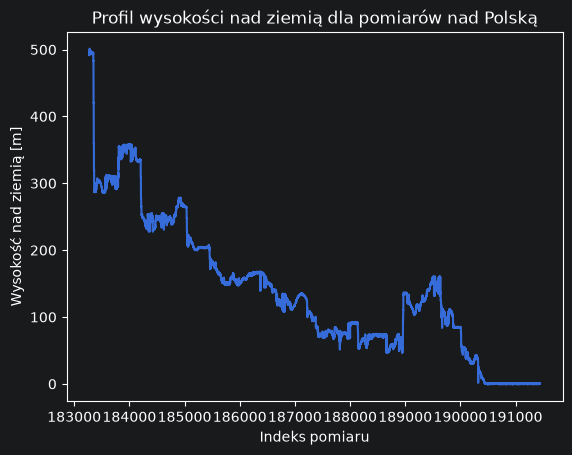

In [62]:
plt.plot(ids, poland_alts)
plt.xlabel("Indeks pomiaru")
plt.ylabel("Wysokość nad ziemią [m]")
plt.title("Profil wysokości nad ziemią dla pomiarów nad Polską")
plt.show()

## Walidacja profilu wysokości (Open-Elevation)

Profil obliczony z pomiaru satelitarnego porównujemy z wysokościami terenu z API [Open-Elevation](https://open-elevation.com/).  
Dla ograniczenia liczby zapytań wybieramy **30 punktów** równomiernie rozłożonych wzdłuż profilu (po jednym na każdy z 30 odcinków).

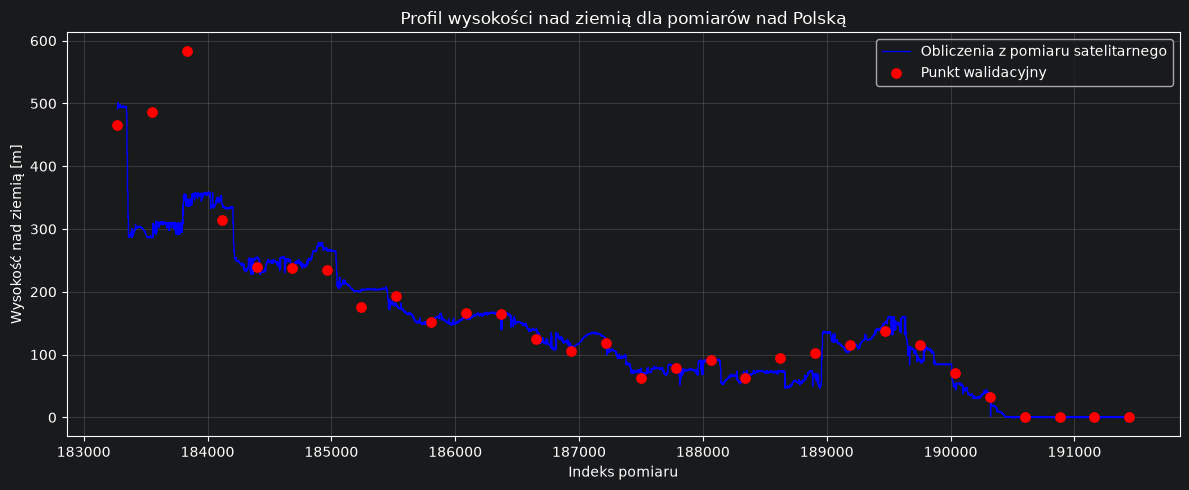

Liczba punktów walidacyjnych: 30
Średnia różnica (obliczenia − API): -13.84 m
Odchylenie standardowe różnicy: 58.29 m
RMSE: 59.91 m
Maksymalna bezwzględna różnica: 244.35 m

Porównanie punkt po punkcie:
  #    Indeks         Lat         Lon   Oblicz. [m]     API [m]    Różnica [m]
------------------------------------------------------------------------------
  1    183271    49.00021    18.48211        491.87      465.00          26.87
  2    183552    49.20737    18.39319        287.09      487.00        -199.91
  3    183834    49.41522    18.30334        339.65      584.00        -244.35
  4    184116    49.62300    18.21285        341.25      314.00          27.25
  5    184398    49.83073    18.12172        253.33      240.00          13.33
  6    184680    50.03841    18.02994        242.06      238.00           4.06
  7    184961    50.24528    17.93782        266.38      234.00          32.38
  8    185243    50.45284    17.84469        203.70      176.00          27.70
  9    

In [63]:
import json
import ssl
import urllib.parse
import urllib.request

N_VALIDATION_POINTS = 30

# Jeden punkt walidacyjny na każdy z 30 równych odcinków profilu
section_positions = np.linspace(0, len(ids) - 1, N_VALIDATION_POINTS, dtype=int)
validation_ids = ids[section_positions].astype(int)
validation_alts = poland_alts[section_positions]

validation_lats = dataset.variables['lat_l1a_echo_sar_ku'][validation_ids]
validation_lons = dataset.variables['lon_l1a_echo_sar_ku'][validation_ids]

# API Open-Elevation: locations=lat,lon|lat,lon|...
locations = "|".join(
    f"{lat:.6f},{lon:.6f}" for lat, lon in zip(validation_lats, validation_lons)
)
query = urllib.parse.urlencode({"locations": locations})
url = f"https://api.open-elevation.com/api/v1/lookup?{query}"

# Certyfikat serwera API bywa wygasły — wyłączamy weryfikację SSL tylko dla tego zapytania
ssl_context = ssl.create_default_context()
ssl_context.check_hostname = False
ssl_context.verify_mode = ssl.CERT_NONE

with urllib.request.urlopen(url, timeout=60, context=ssl_context) as response:
    api_data = json.loads(response.read().decode())

reference_elevations = np.array([point["elevation"] for point in api_data["results"]])
elevation_diff = validation_alts - reference_elevations

plt.figure(figsize=(12, 5))
plt.plot(ids, poland_alts, color="blue", linewidth=1, label="Obliczenia z pomiaru satelitarnego")
plt.scatter(
    validation_ids,
    reference_elevations,
    color="red",
    s=45,
    zorder=5,
    label=f"Punkt walidacyjny",
)
plt.xlabel("Indeks pomiaru")
plt.ylabel("Wysokość nad ziemią [m]")
plt.title("Profil wysokości nad ziemią dla pomiarów nad Polską")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Liczba punktów walidacyjnych: {N_VALIDATION_POINTS}")
print(f"Średnia różnica (obliczenia − API): {np.mean(elevation_diff):.2f} m")
print(f"Odchylenie standardowe różnicy: {np.std(elevation_diff):.2f} m")
print(f"RMSE: {np.sqrt(np.mean(elevation_diff ** 2)):.2f} m")
print(f"Maksymalna bezwzględna różnica: {np.max(np.abs(elevation_diff)):.2f} m")
print()
print("Porównanie punkt po punkcie:")
print(f"{'#':>3}  {'Indeks':>8}  {'Lat':>10}  {'Lon':>10}  {'Oblicz. [m]':>12}  {'API [m]':>10}  {'Różnica [m]':>13}")
print("-" * 78)

for i, (idx, lat, lon, computed, reference, diff) in enumerate(
    zip(validation_ids, validation_lats, validation_lons, validation_alts, reference_elevations, elevation_diff),
    start=1,
):
    print(
        f"{i:3d}  {idx:8d}  {lat:10.5f}  {lon:10.5f}  {computed:12.2f}  {reference:10.2f}  {diff:13.2f}"
    )

In [64]:
# dataset.close()